In [10]:
import pickle

In [11]:
plot_data = {
    'fpocketR': pickle.load(open('plot_data/fpocketR_binding_site_inference_results.pkl', 'rb')),
    'SMARTBind': pickle.load(open('plot_data/SMARTBind_binding_site_inference_results.pkl', 'rb')),
    'RNAsite': pickle.load(open('plot_data/RNAsite_binding_site_inference_results.pkl', 'rb')),
    'RLsite': pickle.load(open('plot_data/RLsite_binding_site_inference_results.pkl', 'rb')),
    'Rsite2': pickle.load(open('plot_data/Rsite2_binding_site_inference_results.pkl', 'rb')),
}

In [12]:
pdb_split_info = {
    "8KED": {"ligand_binder": "GUN",   "homology_based": 0, "ligand_based": 1},
    "8K7W": {"ligand_binder": "2ZY",   "homology_based": 1, "ligand_based": 0},
    "8KHH": {"ligand_binder": "GMP",   "homology_based": 0, "ligand_based": 0},
    "8KEB": {"ligand_binder": "GNG",   "homology_based": 0, "ligand_based": 0},
    "8SYK": {"ligand_binder": "TAC",   "homology_based": 0, "ligand_based": 0},
    "8T5O": {"ligand_binder": "TAC",   "homology_based": 0, "ligand_based": 0},
    "8ZAU": {"ligand_binder": "GUN",   "homology_based": 1, "ligand_based": 1},
    "8Z8Q": {"ligand_binder": "GNG",   "homology_based": 0, "ligand_based": 0},
    "9IOU": {"ligand_binder": "53D",   "homology_based": 1, "ligand_based": 0},
    "9IOS": {"ligand_binder": "53D",   "homology_based": 1, "ligand_based": 0},
    "9IO0": {"ligand_binder": "53D",   "homology_based": 1, "ligand_based": 0},
    "9IOR": {"ligand_binder": "53D",   "homology_based": 1, "ligand_based": 0},
    "9IO1": {"ligand_binder": "53D",   "homology_based": 1, "ligand_based": 0},
    "9MQT": {"ligand_binder": "A1BNU", "homology_based": 1, "ligand_based": 1},
    "9MQS": {"ligand_binder": "5GP",   "homology_based": 1, "ligand_based": 0},
    "9FN2": {"ligand_binder": "SAH",   "homology_based": 1, "ligand_based": 0},
    "9LKU": {"ligand_binder": "GMP",   "homology_based": 0, "ligand_based": 0},
    "9LKW": {"ligand_binder": "GUN",   "homology_based": 0, "ligand_based": 1},
    "9LKC": {"ligand_binder": "GNG",   "homology_based": 0, "ligand_based": 0},
    "9LKF": {"ligand_binder": "GMP",   "homology_based": 0, "ligand_based": 0},
    "9V4X": {"ligand_binder": "9QC",   "homology_based": 0, "ligand_based": 1},
    "9V4Y": {"ligand_binder": "ANG",   "homology_based": 0, "ligand_based": 0},
    "9V4U": {"ligand_binder": "NPR",   "homology_based": 0, "ligand_based": 0},
    "9LJN": {"ligand_binder": "GUN",   "homology_based": 0, "ligand_based": 1},
    "9V50": {"ligand_binder": "A1LXN", "homology_based": 0, "ligand_based": 1},
    "9HRO": {"ligand_binder": "TOY",   "homology_based": 1, "ligand_based": 0},
    "9IWF": {"ligand_binder": "XAN",   "homology_based": 0, "ligand_based": 1},
    "9I9W": {"ligand_binder": "B2R",   "homology_based": 1, "ligand_based": 1},
    "8ZNQ": {"ligand_binder": "NAZ",   "homology_based": 1, "ligand_based": 1},
    "9LKE": {"ligand_binder": "HPA",   "homology_based": 0, "ligand_based": 1},
    "9IWG": {"ligand_binder": "XAN",   "homology_based": 0, "ligand_based": 1},
    "9EC4": {"ligand_binder": "CTI",   "homology_based": 1, "ligand_based": 0},
    "9EBP": {"ligand_binder": "LUM",   "homology_based": 1, "ligand_based": 1},
    "9LKV": {"ligand_binder": "GNG",   "homology_based": 0, "ligand_based": 0},
}

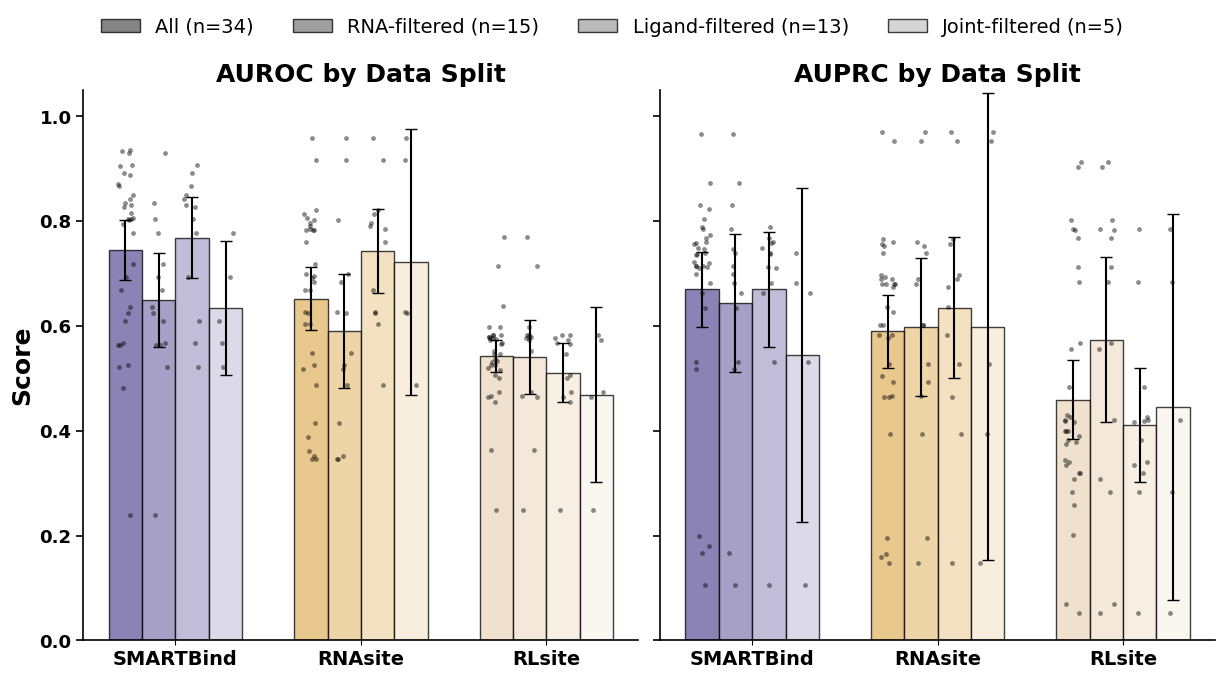

=== Split summary (per-PDB aggregated) ===

All (n=34)
  SMARTBind  | AUROC=0.745+/-0.057, AUPRC=0.670+/-0.072
  RNAsite    | AUROC=0.652+/-0.060, AUPRC=0.590+/-0.070
  RLsite     | AUROC=0.543+/-0.031, AUPRC=0.459+/-0.076

RNA-filtered (n=15)
  SMARTBind  | AUROC=0.650+/-0.090, AUPRC=0.644+/-0.131
  RNAsite    | AUROC=0.590+/-0.109, AUPRC=0.598+/-0.132
  RLsite     | AUROC=0.542+/-0.071, AUPRC=0.574+/-0.158

Ligand-filtered (n=13)
  SMARTBind  | AUROC=0.768+/-0.078, AUPRC=0.670+/-0.110
  RNAsite    | AUROC=0.742+/-0.080, AUPRC=0.635+/-0.134
  RLsite     | AUROC=0.511+/-0.056, AUPRC=0.411+/-0.108

Joint-filtered (n=5)
  SMARTBind  | AUROC=0.634+/-0.128, AUPRC=0.544+/-0.319
  RNAsite    | AUROC=0.723+/-0.254, AUPRC=0.598+/-0.446
  RLsite     | AUROC=0.469+/-0.167, AUPRC=0.445+/-0.369


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import stats as sp_stats
from sklearn.metrics import roc_auc_score, average_precision_score

# Settings
models = ['SMARTBind', 'RNAsite', 'RLsite']
metrics = ['AUROC', 'AUPRC']
splits = ['All', 'RNA-filtered', 'Ligand-filtered', 'Joint-filtered']

base_model_colors = {
    'SMARTBind': '#64599C',
    'fpocketR': '#B8A8D4',
    'RNAsite': '#E2B668',
    'RLsite': '#ECD8BE',
    'Rsite2': '#E9E7F0',
}

split_legend_colors = {
    'All': '#5C5C5C',
    'RNA-filtered': '#808080',
    'Ligand-filtered': '#A5A5A5',
    'Joint-filtered': '#C8C8C8',
}


def extract_pdb_id(sample_key):
    return str(sample_key).split('_')[0]


def mean_ci95(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return (np.nan, np.nan)
    if vals.size == 1:
        return (float(vals.mean()), 0.0)
    m = float(vals.mean())
    se = float(vals.std(ddof=1) / np.sqrt(vals.size))
    ci = se * sp_stats.t.ppf(0.975, df=vals.size - 1)
    return (m, float(ci))


def create_gradient_colors(base_color, n=4):
    """Create n gradient colors from base color (darker to lighter)."""
    base_rgb = mcolors.to_rgb(base_color)
    colors = []
    for i in range(n):
        factor = 1.0 - 0.7 * (i / max(1, n - 1))
        new_rgb = tuple(1 - factor * (1 - c) for c in base_rgb)
        colors.append(new_rgb)
    return colors


def aggregate_metric_dict_per_pdb(metric_dict):
    """metric_dict: {pdb_id: [values]} -> {pdb_id: mean_value}"""
    out = {}
    for pdb_id, vals in metric_dict.items():
        arr = np.asarray(vals, dtype=float)
        arr = arr[np.isfinite(arr)]
        if arr.size > 0:
            out[pdb_id] = float(arr.mean())
    return out


model_gradients = {
    m: create_gradient_colors(base_model_colors[m], n=len(splits))
    for m in models
}

# Raw storage: split -> model -> metric -> pdb_id -> [values]
per_pdb_raw = {
    split: {m: {metric: {} for metric in metrics} for m in models}
    for split in splits
}

valid_pdbs_by_split = {split: set() for split in splits}
missing_split_info = set()

# Compute AUROC/AUPRC per sample, then aggregate by PDB
for model_name in models:
    data = plot_data[model_name]
    for key, entry in data.items():
        pdb_id = extract_pdb_id(key)
        split_info = pdb_split_info.get(pdb_id)
        if split_info is None:
            missing_split_info.add(pdb_id)
            continue

        y_true = np.asarray(entry['groundtruth'], dtype=int)
        y_score = np.asarray(entry['prediction'], dtype=float)

        if len(np.unique(y_true)) < 2:
            continue

        is_homology = int(split_info.get('homology_based', 0)) == 1
        is_ligand = int(split_info.get('ligand_based', 0)) == 1

        split_flags = ['All']
        if is_homology:
            split_flags.append('RNA-filtered')
        if is_ligand:
            split_flags.append('Ligand-filtered')
        if is_homology and is_ligand:
            split_flags.append('Joint-filtered')

        try:
            auroc_val = float(roc_auc_score(y_true, y_score))
        except ValueError:
            auroc_val = np.nan

        try:
            auprc_val = float(average_precision_score(y_true, y_score))
        except ValueError:
            auprc_val = np.nan

        metric_vals = {
            'AUROC': auroc_val,
            'AUPRC': auprc_val,
        }

        for split_name in split_flags:
            valid_pdbs_by_split[split_name].add(pdb_id)
            for metric_name, val in metric_vals.items():
                if np.isfinite(val):
                    per_pdb_raw[split_name][model_name][metric_name].setdefault(pdb_id, []).append(val)

per_pdb = {
    split: {
        m: {
            metric: aggregate_metric_dict_per_pdb(per_pdb_raw[split][m][metric])
            for metric in metrics
        }
        for m in models
    }
    for split in splits
}

plot_values = {
    split: {
        m: {
            metric: list(per_pdb[split][m][metric].values())
            for metric in metrics
        }
        for m in models
    }
    for split in splits
}

stats = {
    split: {
        m: {
            metric: mean_ci95(plot_values[split][m][metric])
            for metric in metrics
        }
        for m in models
    }
    for split in splits
}

# Plot AUROC and AUPRC bar plots by split
fig, axes = plt.subplots(1, 2, figsize=(13*0.95, 7.2*0.95), sharey=True)
width = 0.18
x = np.arange(len(models), dtype=float)
rng = np.random.default_rng(42)

for ax, metric_name in zip(axes, metrics):
    for i, split_name in enumerate(splits):
        offset = width * (i - (len(splits) - 1) / 2)

        for j, model_name in enumerate(models):
            mean_val, ci95 = stats[split_name][model_name][metric_name]
            color = model_gradients[model_name][i]

            ax.bar(
                x[j] + offset,
                mean_val,
                width,
                yerr=ci95,
                color=color,
                alpha=0.75,
                capsize=4,
                edgecolor='black',
                linewidth=1,
            )

            vals = np.asarray(plot_values[split_name][model_name][metric_name], dtype=float)
            vals = vals[np.isfinite(vals)]
            if vals.size > 0:
                jitter = rng.uniform(-width * 0.25, width * 0.25, size=vals.size)
                ax.scatter(
                    np.full(vals.size, x[j] + offset) + jitter,
                    vals,
                    color='black',
                    s=12,
                    alpha=0.45,
                    zorder=10,
                    linewidths=0,
                )

    ax.set_title(f'{metric_name} by Data Split', fontsize=18, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=14, rotation=0, ha='center', fontweight='bold')
    ax.set_ylim(0.0, 1.05)
    ax.tick_params(axis='y', labelsize=13, width=1.2, length=5)
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)

axes[0].set_ylabel('Score', fontsize=18, fontweight='bold')

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, fc=split_legend_colors[s], ec='black', linewidth=1, alpha=0.75)
    for s in splits
]
legend_labels = [f'{s} (n={len(valid_pdbs_by_split[s])})' for s in splits]

fig.legend(
    legend_handles,
    legend_labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.0),
    ncol=4,
    fontsize=14,
    frameon=False,
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('figure3_auroc_auprc_four_splits.png', dpi=600, bbox_inches='tight')
plt.savefig('figure3_auroc_auprc_four_splits.pdf', dpi=600, bbox_inches='tight')
plt.show()

print('=== Split summary (per-PDB aggregated) ===')
for split_name in splits:
    print(f'\n{split_name} (n={len(valid_pdbs_by_split[split_name])})')
    for model_name in models:
        auroc_mean, auroc_ci = stats[split_name][model_name]['AUROC']
        auprc_mean, auprc_ci = stats[split_name][model_name]['AUPRC']
        print(
            f"  {model_name:10s} | "
            f"AUROC={auroc_mean:.3f}+/-{auroc_ci:.3f}, "
            f"AUPRC={auprc_mean:.3f}+/-{auprc_ci:.3f}"
        )

if missing_split_info:
    print('\nWarning: missing pdb_split_info for:', sorted(missing_split_info))

SMARTBind: Youden thr=0.6190
fpocketR: Youden thr=1.0000
RNAsite: Youden thr=0.2920
RLsite: Youden thr=0.7241
Rsite2: Youden thr=0.0000


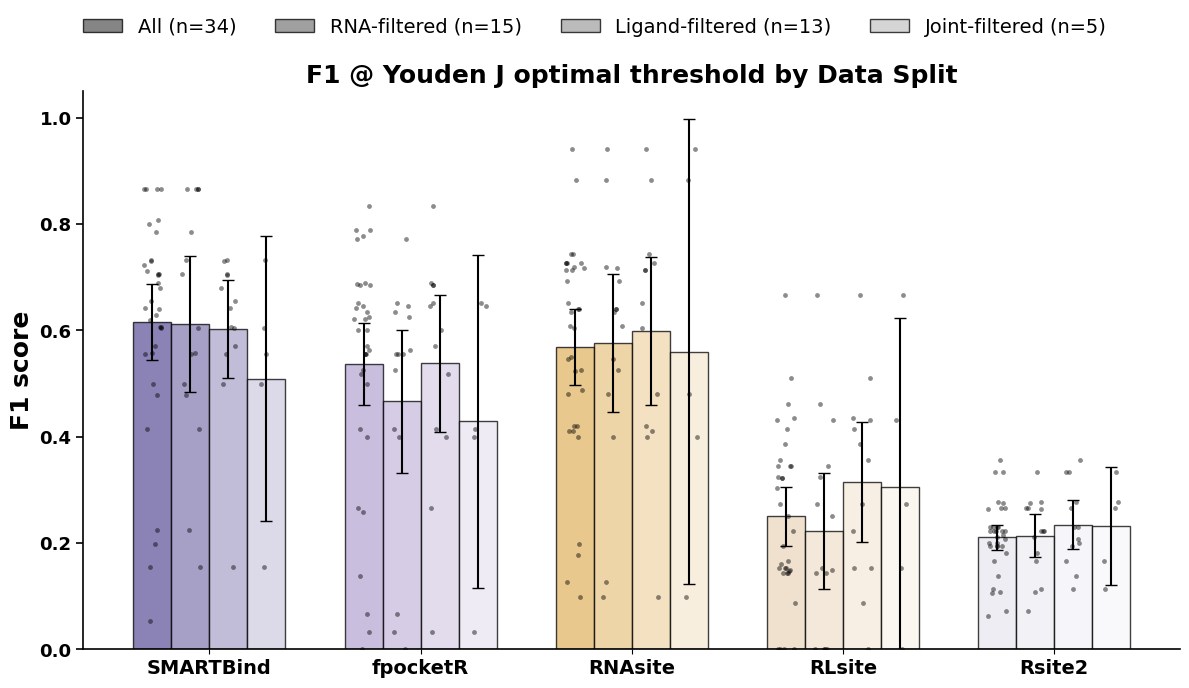

=== Split summary (per-PDB aggregated, F1 @ Youden) ===

All (n=34)
  SMARTBind  | F1=0.616+/-0.071
  fpocketR   | F1=0.537+/-0.077
  RNAsite    | F1=0.569+/-0.071
  RLsite     | F1=0.250+/-0.056
  Rsite2     | F1=0.211+/-0.024

RNA-filtered (n=15)
  SMARTBind  | F1=0.612+/-0.128
  fpocketR   | F1=0.466+/-0.134
  RNAsite    | F1=0.577+/-0.130
  RLsite     | F1=0.223+/-0.109
  Rsite2     | F1=0.213+/-0.041

Ligand-filtered (n=13)
  SMARTBind  | F1=0.603+/-0.092
  fpocketR   | F1=0.538+/-0.129
  RNAsite    | F1=0.599+/-0.139
  RLsite     | F1=0.315+/-0.113
  Rsite2     | F1=0.234+/-0.046

Joint-filtered (n=5)
  SMARTBind  | F1=0.509+/-0.268
  fpocketR   | F1=0.429+/-0.313
  RNAsite    | F1=0.560+/-0.437
  RLsite     | F1=0.305+/-0.319
  Rsite2     | F1=0.232+/-0.111


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import stats as sp_stats
from sklearn.metrics import f1_score, roc_curve

models = ['SMARTBind', 'fpocketR', 'RNAsite', 'RLsite', 'Rsite2']
metrics = ['F1']
splits = ['All', 'RNA-filtered', 'Ligand-filtered', 'Joint-filtered']

base_model_colors = {
    'SMARTBind': '#64599C',
    'fpocketR': '#B8A8D4',
    'RNAsite': '#E2B668',
    'RLsite': '#ECD8BE',
    'Rsite2': '#E9E7F0',
}

split_legend_colors = {
    'All': '#5C5C5C',
    'RNA-filtered': '#808080',
    'Ligand-filtered': '#A5A5A5',
    'Joint-filtered': '#C8C8C8',
}


def extract_pdb_id(sample_key):
    return str(sample_key).split('_')[0]


def mean_ci95(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return (np.nan, np.nan)
    if vals.size == 1:
        return (float(vals.mean()), 0.0)
    m = float(vals.mean())
    se = float(vals.std(ddof=1) / np.sqrt(vals.size))
    ci = se * sp_stats.t.ppf(0.975, df=vals.size - 1)
    return (m, float(ci))


def create_gradient_colors(base_color, n=4):
    """Create n gradient colors from base color (darker to lighter)."""
    base_rgb = mcolors.to_rgb(base_color)
    colors = []
    for i in range(n):
        factor = 1.0 - 0.7 * (i / max(1, n - 1))
        new_rgb = tuple(1 - factor * (1 - c) for c in base_rgb)
        colors.append(new_rgb)
    return colors


def aggregate_metric_dict_per_pdb(metric_dict):
    """metric_dict: {pdb_id: [values]} -> {pdb_id: mean_value}"""
    out = {}
    for pdb_id, vals in metric_dict.items():
        arr = np.asarray(vals, dtype=float)
        arr = arr[np.isfinite(arr)]
        if arr.size > 0:
            out[pdb_id] = float(arr.mean())
    return out


def macro_youden_threshold_per_target(data):
    targets = []
    candidate_thresholds = set()
    for key, entry in data.items():
        y_true = np.asarray(entry['groundtruth'], dtype=int)
        y_score = np.asarray(entry['prediction'], dtype=float)
        if len(np.unique(y_true)) < 2:
            continue
        targets.append((y_true, y_score))
        _, _, thr = roc_curve(y_true, y_score)
        for t in thr:
            if np.isfinite(t):
                candidate_thresholds.add(float(t))
    if not targets or not candidate_thresholds:
        return 0.5

    candidate_thresholds = np.array(sorted(candidate_thresholds), dtype=float)
    best_thr, best_j = 0.5, -np.inf

    for thr in candidate_thresholds:
        tpr_list, fpr_list = [], []
        for y_true, y_score in targets:
            y_pred = (y_score >= thr).astype(int)
            tp = ((y_pred == 1) & (y_true == 1)).sum()
            fn = ((y_pred == 0) & (y_true == 1)).sum()
            fp = ((y_pred == 1) & (y_true == 0)).sum()
            tn = ((y_pred == 0) & (y_true == 0)).sum()
            tpr_list.append(tp / (tp + fn) if (tp + fn) > 0 else 0.0)
            fpr_list.append(fp / (fp + tn) if (fp + tn) > 0 else 0.0)
        mean_j = float(np.mean(tpr_list) - np.mean(fpr_list))
        if mean_j > best_j:
            best_j = mean_j
            best_thr = float(thr)

    return best_thr


model_gradients = {
    m: create_gradient_colors(base_model_colors[m], n=len(splits))
    for m in models
}

# Model-specific Youden thresholds from all valid targets
global_youden_thresholds = {}
for model_name in models:
    global_youden_thresholds[model_name] = macro_youden_threshold_per_target(plot_data[model_name])
    print(f"{model_name}: Youden thr={global_youden_thresholds[model_name]:.4f}")

# Raw storage: split -> model -> metric -> pdb_id -> [values]
per_pdb_raw = {
    split: {m: {metric: {} for metric in metrics} for m in models}
    for split in splits
}

valid_pdbs_by_split = {split: set() for split in splits}
missing_split_info = set()

# Compute F1 @ Youden threshold per sample, then aggregate by PDB
for model_name in models:
    data = plot_data[model_name]
    thr = global_youden_thresholds[model_name]
    use_strict_gt = (model_name == 'Rsite2')

    for key, entry in data.items():
        pdb_id = extract_pdb_id(key)
        split_info = pdb_split_info.get(pdb_id)
        if split_info is None:
            missing_split_info.add(pdb_id)
            continue

        y_true = np.asarray(entry['groundtruth'], dtype=int)
        y_score = np.asarray(entry['prediction'], dtype=float)

        if len(np.unique(y_true)) < 2:
            continue

        is_homology = int(split_info.get('homology_based', 0)) == 1
        is_ligand = int(split_info.get('ligand_based', 0)) == 1

        split_flags = ['All']
        if is_homology:
            split_flags.append('RNA-filtered')
        if is_ligand:
            split_flags.append('Ligand-filtered')
        if is_homology and is_ligand:
            split_flags.append('Joint-filtered')

        y_pred = (y_score > thr).astype(int) if use_strict_gt else (y_score >= thr).astype(int)
        f1_val = float(f1_score(y_true, y_pred, zero_division=0))

        for split_name in split_flags:
            valid_pdbs_by_split[split_name].add(pdb_id)
            if np.isfinite(f1_val):
                per_pdb_raw[split_name][model_name]['F1'].setdefault(pdb_id, []).append(f1_val)

per_pdb = {
    split: {
        m: {
            metric: aggregate_metric_dict_per_pdb(per_pdb_raw[split][m][metric])
            for metric in metrics
        }
        for m in models
    }
    for split in splits
}

plot_values = {
    split: {
        m: {
            metric: list(per_pdb[split][m][metric].values())
            for metric in metrics
        }
        for m in models
    }
    for split in splits
}

stats = {
    split: {
        m: {
            metric: mean_ci95(plot_values[split][m][metric])
            for metric in metrics
        }
        for m in models
    }
    for split in splits
}

# -----------------------------
# Plot F1 by split
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 7))
width = 0.18
x = np.arange(len(models), dtype=float)
rng = np.random.default_rng(42)

for i, split_name in enumerate(splits):
    offset = width * (i - (len(splits) - 1) / 2)

    for j, model_name in enumerate(models):
        mean_val, ci95 = stats[split_name][model_name]['F1']
        color = model_gradients[model_name][i]

        ax.bar(
            x[j] + offset,
            mean_val,
            width,
            yerr=ci95,
            color=color,
            alpha=0.75,
            capsize=4,
            edgecolor='black',
            linewidth=1,
        )

        vals = np.asarray(plot_values[split_name][model_name]['F1'], dtype=float)
        vals = vals[np.isfinite(vals)]
        if vals.size > 0:
            jitter = rng.uniform(-width * 0.25, width * 0.25, size=vals.size)
            ax.scatter(
                np.full(vals.size, x[j] + offset) + jitter,
                vals,
                color='black',
                s=12,
                alpha=0.45,
                zorder=10,
                linewidths=0,
            )

ax.set_title('F1 @ Youden J optimal threshold by Data Split', fontsize=18, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=14, rotation=0, ha='center', fontweight='bold')
ax.set_ylim(0.0, 1.05)
ax.set_ylabel('F1 score', fontsize=18, fontweight='bold')
ax.tick_params(axis='y', labelsize=13, width=1.2, length=5)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, fc=split_legend_colors[s], ec='black', linewidth=1, alpha=0.75)
    for s in splits
]
legend_labels = [f'{s} (n={len(valid_pdbs_by_split[s])})' for s in splits]

fig.legend(
    legend_handles,
    legend_labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.99),
    ncol=4,
    fontsize=14,
    frameon=False,
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig('figure3_f1_youden_four_splits.png', dpi=600, bbox_inches='tight')
plt.savefig('figure3_f1_youden_four_splits.pdf', dpi=600, bbox_inches='tight')
plt.show()

print('=== Split summary (per-PDB aggregated, F1 @ Youden) ===')
for split_name in splits:
    print(f'\n{split_name} (n={len(valid_pdbs_by_split[split_name])})')
    for model_name in models:
        f1_mean, f1_ci = stats[split_name][model_name]['F1']
        print(f"  {model_name:10s} | F1={f1_mean:.3f}+/-{f1_ci:.3f}")

if missing_split_info:
    print('\nWarning: missing pdb_split_info for:', sorted(missing_split_info))

SMARTBind: Youden thr=0.6190, FixedRecall0.8 thr=0.5670
fpocketR: Youden thr=1.0000, FixedRecall0.8 thr=0.0000
RNAsite: Youden thr=0.2920, FixedRecall0.8 thr=0.2130
RLsite: Youden thr=0.7241, FixedRecall0.8 thr=0.5018
Rsite2: Youden thr=0.0000, FixedRecall0.8 thr=0.0000


/blue/yanjun.li/pfq7pm.virginia/.conda/envs/smartbind_prev/lib/python3.9/site-packages/scipy/stats/_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


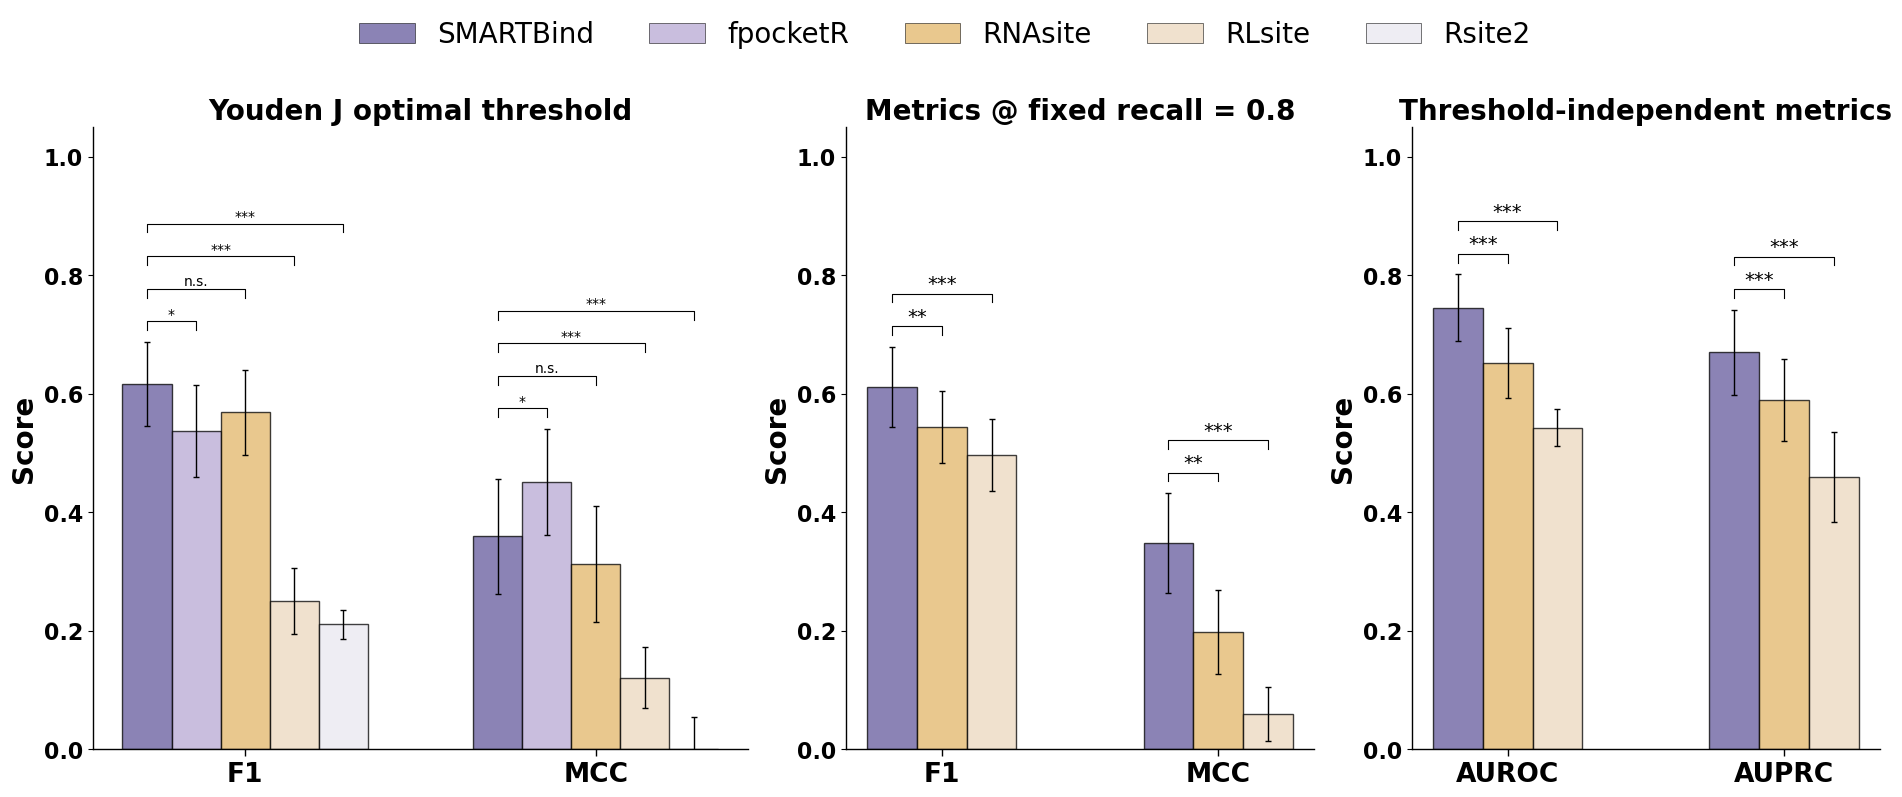


=== Global thresholds ===
  SMARTBind: Youden=0.6190, FixedRecall0.8=0.5670
  fpocketR: Youden=1.0000, FixedRecall0.8=0.0000
  RNAsite: Youden=0.2920, FixedRecall0.8=0.2130
  RLsite: Youden=0.7241, FixedRecall0.8=0.5018
  Rsite2: Youden=0.0000, FixedRecall0.8=0.0000

=== Figure 1 Left (Youden: F1/MCC, per-PDB aggregated) ===
  SMARTBind: F1=0.616+/-0.071, MCC=0.360+/-0.097
  fpocketR: F1=0.537+/-0.077, MCC=0.451+/-0.090
  RNAsite: F1=0.569+/-0.071, MCC=0.313+/-0.098
  RLsite: F1=0.250+/-0.056, MCC=0.121+/-0.052
  Rsite2: F1=0.211+/-0.024, MCC=-0.007+/-0.062

=== Figure 1 Right (FixedRecall0.8: F1/MCC, per-PDB aggregated) ===
  SMARTBind: F1=0.612+/-0.068, MCC=0.348+/-0.084
  RNAsite: F1=0.544+/-0.061, MCC=0.198+/-0.071
  RLsite: F1=0.496+/-0.061, MCC=0.059+/-0.046

=== Figure 2 (AUROC/AUPRC, per-PDB aggregated) ===
  SMARTBind: AUROC=0.745+/-0.057, AUPRC=0.670+/-0.072
  RNAsite: AUROC=0.652+/-0.060, AUPRC=0.590+/-0.070
  RLsite: AUROC=0.543+/-0.031, AUPRC=0.459+/-0.076

=== Wilcoxon p

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp_stats
from sklearn.metrics import (
    f1_score, matthews_corrcoef, roc_auc_score,
    average_precision_score, roc_curve
)

# -- Helper functions --------------------------------------------------
def metrics_at_threshold(y_true, y_score, thr, use_strict_gt=False):
    y_true = np.asarray(y_true, dtype=int)
    y_score = np.asarray(y_score, dtype=float)
    y_pred = (y_score > thr).astype(int) if use_strict_gt else (y_score >= thr).astype(int)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred)
    return f1, mcc

def decision_metrics_at_threshold(y_true, y_score, thr, use_strict_gt=False):
    y_true = np.asarray(y_true, dtype=int)
    y_score = np.asarray(y_score, dtype=float)
    y_pred = (y_score > thr).astype(int) if use_strict_gt else (y_score >= thr).astype(int)

    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return float(precision), float(recall), float(specificity)

def mean_ci95(vals):
    """Return (mean, ci95_half_width) for 95% CI."""
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return (np.nan, np.nan)
    if vals.size == 1:
        return (float(vals.mean()), 0.0)
    m = float(vals.mean())
    se = float(vals.std(ddof=1) / np.sqrt(vals.size))
    ci = se * sp_stats.t.ppf(0.975, df=vals.size - 1)
    return (m, ci)

def macro_youden_threshold_per_target(data):
    targets = []
    candidate_thresholds = set()
    for key, entry in data.items():
        y_true = np.asarray(entry['groundtruth'], dtype=int)
        y_score = np.asarray(entry['prediction'], dtype=float)
        if len(np.unique(y_true)) < 2:
            continue
        targets.append((y_true, y_score))
        _, _, thr = roc_curve(y_true, y_score)
        for t in thr:
            if np.isfinite(t):
                candidate_thresholds.add(float(t))
    if not targets or not candidate_thresholds:
        return 0.5
    candidate_thresholds = np.array(sorted(candidate_thresholds), dtype=float)
    best_thr, best_j = 0.5, -np.inf
    for thr in candidate_thresholds:
        tpr_list, fpr_list = [], []
        for y_true, y_score in targets:
            y_pred = (y_score >= thr).astype(int)
            tp = ((y_pred == 1) & (y_true == 1)).sum()
            fn = ((y_pred == 0) & (y_true == 1)).sum()
            fp = ((y_pred == 1) & (y_true == 0)).sum()
            tn = ((y_pred == 0) & (y_true == 0)).sum()
            tpr_list.append(tp / (tp + fn) if (tp + fn) > 0 else 0.0)
            fpr_list.append(fp / (fp + tn) if (fp + tn) > 0 else 0.0)
        mean_j = float(np.mean(tpr_list) - np.mean(fpr_list))
        if mean_j > best_j:
            best_j = mean_j
            best_thr = float(thr)
    return best_thr

def macro_threshold_for_fixed_recall_per_target(data, target_recall=0.8):
    targets = []
    candidate_thresholds = set()
    all_scores = []
    for key, entry in data.items():
        y_true = np.asarray(entry['groundtruth'], dtype=int)
        y_score = np.asarray(entry['prediction'], dtype=float)
        if len(np.unique(y_true)) < 2:
            continue
        targets.append((y_true, y_score))
        all_scores.append(y_score)
        _, _, thr = roc_curve(y_true, y_score)
        for t in thr:
            if np.isfinite(t):
                candidate_thresholds.add(float(t))
    if not targets:
        return 0.5
    all_scores = np.concatenate(all_scores)
    if not candidate_thresholds:
        candidate_thresholds = set(map(float, np.unique(all_scores)))
    candidate_thresholds = np.array(sorted(candidate_thresholds), dtype=float)
    ok_thresholds = []
    for thr in candidate_thresholds:
        recalls = []
        for y_true, y_score in targets:
            y_pred = (y_score >= thr).astype(int)
            tp = ((y_pred == 1) & (y_true == 1)).sum()
            fn = ((y_pred == 0) & (y_true == 1)).sum()
            recalls.append(tp / (tp + fn) if (tp + fn) > 0 else 0.0)
        if float(np.mean(recalls)) >= target_recall:
            ok_thresholds.append(float(thr))
    if not ok_thresholds:
        return float(np.min(all_scores) - 1e-12)
    return float(np.max(ok_thresholds))

def p_to_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'n.s.'

def extract_pdb_id(sample_key):
    return str(sample_key).split('_')[0]

def aggregate_metric_dict_per_pdb(metric_dict):
    """metric_dict: {pdb_id: [values]} -> {pdb_id: mean_value}"""
    out = {}
    for pdb_id, vals in metric_dict.items():
        arr = np.asarray(vals, dtype=float)
        arr = arr[np.isfinite(arr)]
        if arr.size > 0:
            out[pdb_id] = float(arr.mean())
    return out

def paired_wilcoxon_from_pdb_dict(sb_dict, ot_dict, min_pairs=5):
    common = sorted(set(sb_dict.keys()) & set(ot_dict.keys()))
    if len(common) < min_pairs:
        return 1.0, len(common)
    sb = np.array([sb_dict[p] for p in common], dtype=float)
    ot = np.array([ot_dict[p] for p in common], dtype=float)
    mask = np.isfinite(sb) & np.isfinite(ot)
    n_pairs = int(mask.sum())
    if n_pairs < min_pairs:
        return 1.0, n_pairs
    try:
        _, p = sp_stats.wilcoxon(sb[mask], ot[mask], alternative='two-sided')
    except ValueError:
        p = 1.0
    return float(p), n_pairs

def fdr_bh(pval_dict):
    """Benjamini-Hochberg FDR correction for dict values."""
    items = list(pval_dict.items())
    m = len(items)
    if m == 0:
        return {}
    pvals = np.array([float(v) for _, v in items], dtype=float)
    order = np.argsort(pvals)
    ranked = pvals[order]
    q_ranked = np.empty(m, dtype=float)
    prev = 1.0
    for i in range(m - 1, -1, -1):
        rank = i + 1
        q = ranked[i] * m / rank
        prev = min(prev, q)
        q_ranked[i] = min(prev, 1.0)
    qvals = np.empty(m, dtype=float)
    qvals[order] = q_ranked
    return {items[i][0]: float(qvals[i]) for i in range(m)}

# -- Compute metrics (all cases) --------------------------------------
model_order = ['SMARTBind', 'fpocketR', 'RNAsite', 'RLsite', 'Rsite2']
model_order_right = ['SMARTBind', 'RNAsite', 'RLsite']

metrics_all = ['F1', 'MCC', 'AUROC', 'AUPRC']
metrics_fixed = ['F1', 'MCC']
metrics_left = ['F1', 'MCC']
metrics_right = ['F1', 'MCC']
metrics_auc = ['AUROC', 'AUPRC']
metrics_prs = ['Precision', 'Recall', 'Specificity']

# Global thresholds per model
global_youden_thresholds = {}
global_fixedrec_thresholds = {}
for model_name in model_order:
    global_youden_thresholds[model_name] = macro_youden_threshold_per_target(plot_data[model_name])
    global_fixedrec_thresholds[model_name] = macro_threshold_for_fixed_recall_per_target(
        plot_data[model_name], target_recall=0.8)
    print(f"{model_name}: Youden thr={global_youden_thresholds[model_name]:.4f}, "
          f"FixedRecall0.8 thr={global_fixedrec_thresholds[model_name]:.4f}")

# Per-structure metrics and aggregate to per-PDB
youden_per_pdb_raw = {m: {metric: {} for metric in metrics_all} for m in model_order}
fixedrec_per_pdb_raw = {m: {metric: {} for metric in metrics_fixed} for m in model_order}
decision_per_pdb_raw = {m: {metric: {} for metric in metrics_prs} for m in model_order}

for model_name in model_order:
    data = plot_data[model_name]
    thr_y = global_youden_thresholds[model_name]
    thr_fr = global_fixedrec_thresholds[model_name]
    for key, entry in data.items():
        pdb_id = extract_pdb_id(key)
        y_true = np.asarray(entry['groundtruth'], dtype=int)
        y_score = np.asarray(entry['prediction'], dtype=float)
        if len(np.unique(y_true)) < 2:
            continue

        try:
            auroc_val = roc_auc_score(y_true, y_score)
        except ValueError:
            auroc_val = np.nan

        try:
            auprc_val = average_precision_score(y_true, y_score)
        except ValueError:
            auprc_val = np.nan

        use_strict_gt = (model_name == 'Rsite2')
        f1_y, mcc_y = metrics_at_threshold(y_true, y_score, thr_y, use_strict_gt=use_strict_gt)
        f1_fr, mcc_fr = metrics_at_threshold(y_true, y_score, thr_fr, use_strict_gt=use_strict_gt)
        precision_y, recall_y, specificity_y = decision_metrics_at_threshold(
            y_true, y_score, thr_y, use_strict_gt=use_strict_gt
        )

        youden_vals = {'F1': f1_y, 'MCC': mcc_y, 'AUROC': auroc_val, 'AUPRC': auprc_val}
        fixed_vals = {'F1': f1_fr, 'MCC': mcc_fr}
        decision_vals = {'Precision': precision_y, 'Recall': recall_y, 'Specificity': specificity_y}

        for metric, val in youden_vals.items():
            youden_per_pdb_raw[model_name][metric].setdefault(pdb_id, []).append(float(val))
        for metric, val in fixed_vals.items():
            fixedrec_per_pdb_raw[model_name][metric].setdefault(pdb_id, []).append(float(val))
        for metric, val in decision_vals.items():
            decision_per_pdb_raw[model_name][metric].setdefault(pdb_id, []).append(float(val))

# Per-model, per-metric mean value for each PDB (used for pairing and summary)
youden_per_pdb = {
    m: {metric: aggregate_metric_dict_per_pdb(youden_per_pdb_raw[m][metric]) for metric in metrics_all}
    for m in model_order
}
fixedrec_per_pdb = {
    m: {metric: aggregate_metric_dict_per_pdb(fixedrec_per_pdb_raw[m][metric]) for metric in metrics_fixed}
    for m in model_order
}
decision_per_pdb = {
    m: {metric: aggregate_metric_dict_per_pdb(decision_per_pdb_raw[m][metric]) for metric in metrics_prs}
    for m in model_order
}

# Lists used for plotting mean +/- CI (one value per PDB)
youden_results = {m: {metric: list(youden_per_pdb[m][metric].values()) for metric in metrics_all} for m in model_order}
fixedrec_results = {m: {metric: list(fixedrec_per_pdb[m][metric].values()) for metric in metrics_fixed} for m in model_order}
decision_results = {m: {metric: list(decision_per_pdb[m][metric].values()) for metric in metrics_prs} for m in model_order}

# Aggregate mean +/- 95% CI
youden_stats = {m: {} for m in model_order}
for m in model_order:
    for metric in metrics_all:
        youden_stats[m][metric] = mean_ci95(youden_results[m][metric])

fixedrec_stats = {m: {} for m in model_order}
for m in model_order:
    for metric in metrics_fixed:
        fixedrec_stats[m][metric] = mean_ci95(fixedrec_results[m][metric])

decision_stats = {m: {} for m in model_order}
for m in model_order:
    for metric in metrics_prs:
        decision_stats[m][metric] = mean_ci95(decision_results[m][metric])

# -- Paired Wilcoxon by PDB alignment: SMARTBind vs others ------------
wilcoxon_left = {}
wilcoxon_left_n = {}
for metric in metrics_left:
    sb_dict = youden_per_pdb['SMARTBind'][metric]
    for other in model_order[1:]:
        ot_dict = youden_per_pdb[other][metric]
        p, n_pairs = paired_wilcoxon_from_pdb_dict(sb_dict, ot_dict, min_pairs=5)
        wilcoxon_left[(metric, other)] = p
        wilcoxon_left_n[(metric, other)] = n_pairs

wilcoxon_right = {}
wilcoxon_right_n = {}
for metric in metrics_right:
    sb_dict = fixedrec_per_pdb['SMARTBind'][metric]
    for other in model_order_right[1:]:
        ot_dict = fixedrec_per_pdb[other][metric]
        p, n_pairs = paired_wilcoxon_from_pdb_dict(sb_dict, ot_dict, min_pairs=5)
        wilcoxon_right[(metric, other)] = p
        wilcoxon_right_n[(metric, other)] = n_pairs

wilcoxon_auc = {}
wilcoxon_auc_n = {}
for metric in metrics_auc:
    sb_dict = youden_per_pdb['SMARTBind'][metric]
    for other in model_order_right[1:]:
        ot_dict = youden_per_pdb[other][metric]
        p, n_pairs = paired_wilcoxon_from_pdb_dict(sb_dict, ot_dict, min_pairs=5)
        wilcoxon_auc[(metric, other)] = p
        wilcoxon_auc_n[(metric, other)] = n_pairs

# FDR correction (BH)
wilcoxon_left_fdr = fdr_bh(wilcoxon_left)
wilcoxon_right_fdr = fdr_bh(wilcoxon_right)
wilcoxon_auc_fdr = fdr_bh(wilcoxon_auc)

# -- Color palette -----------------------------------------------------
palette = {
    'SMARTBind': '#64599C',
    'fpocketR':  '#B8A8D4',
    'RNAsite':   '#E2B668',
    'RLsite':    '#ECD8BE',
    'Rsite2':    '#E9E7F0',
}

# -- Helper: draw significance bracket --------------------------------
def add_sig_bracket(ax, x1, x2, y, h, text, fontsize=11):
    """Draw a bracket between x1 and x2 at height y with text."""
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=0.8, c='black')
    ax.text((x1 + x2) / 2, y + h, text, ha='center', va='bottom', fontsize=fontsize)

# -- Figure 1: Youden + Fixed Recall + AUROC/AUPRC --------------------
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(19, 7.2), gridspec_kw={'width_ratios': [1.4, 1, 1]})

n_models_left = len(model_order)
n_models_right = len(model_order_right)
bar_width = 0.14
edgecolor = 'black'

# Store bar x positions for significance lines
bar_x_left = {}
bar_x_right = {}
bar_x_auc = {}

# Left panel (F1/MCC @ Youden, five models)
for i, metric in enumerate(metrics_left):
    for j, model in enumerate(model_order):
        mean, ci = youden_stats[model][metric]
        x = i + (j - n_models_left / 2 + 0.5) * bar_width
        bar_x_left[(i, model)] = x
        ax1.bar(x, mean, bar_width, yerr=ci, color=palette[model], alpha=0.75,
                edgecolor=edgecolor, linewidth=1, capsize=2,
                error_kw={'linewidth': 1, 'capthick': 1})

ax1.set_xticks(range(len(metrics_left)))
ax1.set_xticklabels(metrics_left, fontsize=19, fontweight='bold')
ax1.set_ylabel('Score', fontsize=20, fontweight='bold')
ax1.set_ylim(0, 1.05)
ax1.set_yticks(np.arange(0, 1.1, 0.2))
ax1.set_title('Youden J optimal threshold', fontsize=20, fontweight='bold')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_linewidth(1)
ax1.spines['left'].set_linewidth(1)
ax1.tick_params(axis='y', labelsize=16)
for label in ax1.get_yticklabels():
    label.set_fontweight('bold')
ax1.tick_params(axis='x', which='both', length=5, width=1)

# Add significance brackets for left panel (stars from FDR-adjusted p)
for i, metric in enumerate(metrics_left):
    x_sb = bar_x_left[(i, 'SMARTBind')]
    max_h = max(youden_stats[m][metric][0] + youden_stats[m][metric][1] for m in model_order)
    bracket_y = max_h + 0.02
    bracket_h = 0.015
    bracket_step = 0.055

    for k, other in enumerate(model_order[1:]):
        x_ot = bar_x_left[(i, other)]
        p_adj = wilcoxon_left_fdr[(metric, other)]
        stars = p_to_stars(p_adj)
        y_pos = bracket_y + k * bracket_step
        add_sig_bracket(ax1, x_sb, x_ot, y_pos, bracket_h, stars, fontsize=10)

# Right panel (F1/MCC @ fixed recall=0.8, three models)
bar_width = 0.18
for i, metric in enumerate(metrics_right):
    for j, model in enumerate(model_order_right):
        mean, ci = fixedrec_stats[model][metric]
        x = i + (j - n_models_right / 2 + 0.5) * bar_width
        bar_x_right[(i, model)] = x
        ax2.bar(x, mean, bar_width, yerr=ci, color=palette[model], alpha=0.75,
                edgecolor=edgecolor, linewidth=1, capsize=2,
                error_kw={'linewidth': 1, 'capthick': 1})

ax2.set_xticks(range(len(metrics_right)))
ax2.set_xticklabels(metrics_right, fontsize=19, fontweight='bold')
ax2.set_ylabel('Score', fontsize=20, fontweight='bold')
ax2.set_ylim(0, 1.05)
ax2.set_yticks(np.arange(0, 1.1, 0.2))
ax2.set_title('Metrics @ fixed recall = 0.8', fontsize=20, fontweight='bold')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_linewidth(1)
ax2.spines['left'].set_linewidth(1)
ax2.tick_params(axis='y', labelsize=16)
for label in ax2.get_yticklabels():
    label.set_fontweight('bold')
ax2.tick_params(axis='x', which='both', length=5, width=1)

# Add significance brackets for right panel (stars from FDR-adjusted p)
for i, metric in enumerate(metrics_right):
    x_sb = bar_x_right[(i, 'SMARTBind')]
    max_h = max(fixedrec_stats[m][metric][0] + fixedrec_stats[m][metric][1] for m in model_order_right)
    bracket_y = max_h + 0.02
    bracket_h = 0.015
    bracket_step = 0.055

    for k, other in enumerate(model_order_right[1:]):
        x_ot = bar_x_right[(i, other)]
        p_adj = wilcoxon_right_fdr[(metric, other)]
        stars = p_to_stars(p_adj)
        y_pos = bracket_y + k * bracket_step
        add_sig_bracket(ax2, x_sb, x_ot, y_pos, bracket_h, stars, fontsize=14)

# Right-most panel (AUROC/AUPRC, three models)
bar_width_auc = 0.18

for i, metric in enumerate(metrics_auc):
    for j, model in enumerate(model_order_right):
        mean, ci = youden_stats[model][metric]
        x = i + (j - len(model_order_right) / 2 + 0.5) * bar_width_auc
        bar_x_auc[(i, model)] = x
        ax3.bar(x, mean, bar_width_auc, yerr=ci, color=palette[model], alpha=0.75,
                edgecolor=edgecolor, linewidth=1, capsize=2,
                error_kw={'linewidth': 1, 'capthick': 1})

ax3.set_xticks(range(len(metrics_auc)))
ax3.set_xticklabels(metrics_auc, fontsize=19, fontweight='bold')
ax3.set_ylabel('Score', fontsize=20, fontweight='bold')
ax3.set_ylim(0, 1.05)
ax3.set_yticks(np.arange(0, 1.1, 0.2))
ax3.set_title('Threshold-independent metrics', fontsize=20, fontweight='bold')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['bottom'].set_linewidth(1)
ax3.spines['left'].set_linewidth(1)
ax3.tick_params(axis='y', labelsize=16)
for label in ax3.get_yticklabels():
    label.set_fontweight('bold')
ax3.tick_params(axis='x', which='both', length=5, width=1)

for i, metric in enumerate(metrics_auc):
    x_sb = bar_x_auc[(i, 'SMARTBind')]
    max_h = max(youden_stats[m][metric][0] + youden_stats[m][metric][1] for m in model_order_right)
    bracket_y = max_h + 0.02
    bracket_h = 0.015
    bracket_step = 0.055

    for k, other in enumerate(model_order_right[1:]):
        x_ot = bar_x_auc[(i, other)]
        p_adj = wilcoxon_auc_fdr[(metric, other)]
        stars = p_to_stars(p_adj)
        y_pos = bracket_y + k * bracket_step
        add_sig_bracket(ax3, x_sb, x_ot, y_pos, bracket_h, stars, fontsize=14)

# Shared legend
handles = [plt.Rectangle((0, 0), 1, 1, facecolor=palette[m], alpha=0.75, edgecolor=edgecolor, linewidth=0.5)
           for m in model_order]
fig.legend(handles, model_order, loc='upper center', ncol=n_models_left,
           fontsize=20, frameon=False, bbox_to_anchor=(0.5, 1.12))
plt.tight_layout()
plt.savefig('benchmark_metrics_multipanel_shared_legend_34cases.png', dpi=600, bbox_inches='tight')
plt.savefig('benchmark_metrics_multipanel_shared_legend_34cases.pdf', dpi=600, bbox_inches='tight')
plt.show()

# -- Print verification ------------------------------------------------
print("\n=== Global thresholds ===")
for m in model_order:
    print(f"  {m}: Youden={global_youden_thresholds[m]:.4f}, FixedRecall0.8={global_fixedrec_thresholds[m]:.4f}")

print("\n=== Figure 1 Left (Youden: F1/MCC, per-PDB aggregated) ===")
for m in model_order:
    parts = [f"{k}={youden_stats[m][k][0]:.3f}+/-{youden_stats[m][k][1]:.3f}" for k in metrics_left]
    print(f"  {m}: " + ", ".join(parts))

print("\n=== Figure 1 Right (FixedRecall0.8: F1/MCC, per-PDB aggregated) ===")
for m in model_order_right:
    parts = [f"{k}={fixedrec_stats[m][k][0]:.3f}+/-{fixedrec_stats[m][k][1]:.3f}" for k in metrics_right]
    print(f"  {m}: " + ", ".join(parts))

print("\n=== Figure 2 (AUROC/AUPRC, per-PDB aggregated) ===")
for m in model_order_right:
    parts = [f"{k}={youden_stats[m][k][0]:.3f}+/-{youden_stats[m][k][1]:.3f}" for k in metrics_auc]
    print(f"  {m}: " + ", ".join(parts))

print("\n=== Wilcoxon p-values (SMARTBind vs others, paired by PDB) ===")
print("Figure 1 Left (Youden F1/MCC):")
for metric in metrics_left:
    for other in model_order[1:]:
        p_raw = wilcoxon_left[(metric, other)]
        p_fdr = wilcoxon_left_fdr[(metric, other)]
        n_pairs = wilcoxon_left_n[(metric, other)]
        print(f"  {metric}: SMARTBind vs {other}: n={n_pairs}, p_raw={p_raw:.4g}, p_fdr={p_fdr:.4g} {p_to_stars(p_fdr)}")

print("Figure 1 Right (FixedRecall0.8 F1/MCC):")
for metric in metrics_right:
    for other in model_order_right[1:]:
        p_raw = wilcoxon_right[(metric, other)]
        p_fdr = wilcoxon_right_fdr[(metric, other)]
        n_pairs = wilcoxon_right_n[(metric, other)]
        print(f"  {metric}: SMARTBind vs {other}: n={n_pairs}, p_raw={p_raw:.4g}, p_fdr={p_fdr:.4g} {p_to_stars(p_fdr)}")

print("Figure 2 (AUROC/AUPRC):")
for metric in metrics_auc:
    for other in model_order_right[1:]:
        p_raw = wilcoxon_auc[(metric, other)]
        p_fdr = wilcoxon_auc_fdr[(metric, other)]
        n_pairs = wilcoxon_auc_n[(metric, other)]
        print(f"  {metric}: SMARTBind vs {other}: n={n_pairs}, p_raw={p_raw:.4g}, p_fdr={p_fdr:.4g} {p_to_stars(p_fdr)}")

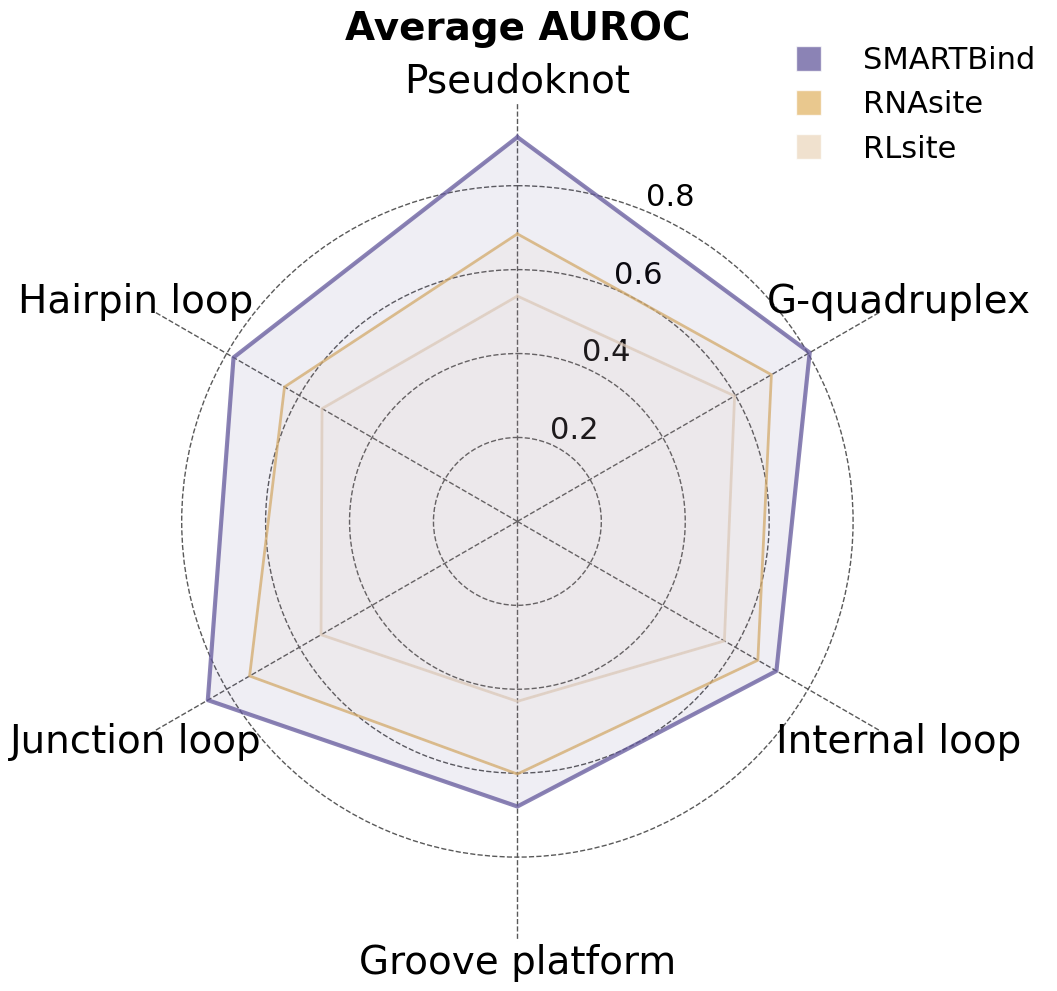

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

raw = r"""
3D motif annotation	AUC				
	SMARTBind	Rsite2	RNAsite	fpocketR	RLsite
Pseudoknot / Junction loop / Hairpin loop	0.9071	0.5412	0.6683	0.7632	0.5374
G-quadruplex / Internal loop	0.8043	0.4448	0.699	0.6957	0.5978
Pseudoknot / Junction loop / Hairpin loop	0.9357	0.5314	0.719	0.7619	0.5362
Pseudoknot / Junction loop / Hairpin loop	0.9047	0.5412	0.6683	0.7368	0.5374
Hairpin loop	0.482	0.4657	0.3616	0.5127	0.5161
Hairpin loop	0.5252	0.4791	0.3881	0.6965	0.5114
Junction loop / Internal loop	0.7783	0.5432	0.625	0.7381	0.5538
Hairpin loop / Junction loop	0.9338	0.5358	0.6912	0.725	0.6224
Internal loop	0.9295	0.3269	0.5256	0.6923	0.5769
Internal loop	0.5643	0.2714	0.45	0.6786	0.7143
Internal loop	0.7179	0.3269	0.3333	0.6923	0.7692
Internal loop	0.625	0.4659	0.2619	0.7273	0.5795
Internal loop	0.5641	0.3269	0.3462	0.6923	0.5513
Groove platform	0.5666	0.5203	0.487	0.464	0.2338
Groove platform	0.6363	0.5129	0.5169	0.4846	0.4977
Groove platform / Junction loop	0.8353	0.4952	0.8023	0.7188	0.5551
Junction loop	0.8878	0.5417	0.6033	0.5222	0.4977
Junction loop	0.8922	0.5417	0.6033	0.5333	0.4837
Internal loop / Junction loop	0.8154	0.507	0.7839	0.8307	0.5250
Internal loop / Junction loop	0.8028	0.507	0.7839	0.8182	0.5250
Internal loop / Junction loop	0.8667	0.5114	0.8214	0.7143	0.5676
Internal loop / Junction loop	0.8062	0.5114	0.8067	0.7143	0.5305
Internal loop / Junction loop	0.7945	0.507	0.7839	0.8307	0.5325
Internal loop / Junction loop	0.8495	0.5162	0.8132	0.8652	0.5647
Junction loop	0.8039	0.4814	0.7961	0.675	0.5020
Internal loop	0.2386	0.5379	0.5492	0.5	0.5795
Hairpin loop / Junction loop	0.8422	0.5982	0.7594	0.7649	0.5774
Internal loop	0.5208	0.4583	0.9583	0.625	0.5833
Internal loop	0.61	0.4163	0.9163	0.4761	0.4785
Internal loop / Junction loop	0.83	0.5057	0.7912	0.7623	0.4545
Hairpin loop / Junction loop	0.828	0.587	0.785	0.6957	0.5822
Hairpin loop	0.6687	0.537	0.6845	0.8148	0.4563
Hairpin loop	0.6936	0.5464	0.6275	0.7464	0.4553
Hairpin loop / Junction loop	0.8708	0.5373	0.6962	0.725	0.5814
""".strip("\n")

lines = raw.splitlines()
header2 = lines[1]  # "\tSMARTBind\tGerNA-Bind\tRNAsite\tfPocketR"
col_models = header2.split("\t")[1:]  # skip first empty cell
MODEL_COLS = col_models

data_lines = [lines[i] for i in range(2, len(lines))]
df_auc = pd.read_csv(
    StringIO("\n".join(data_lines)),
    sep="\t",
    header=None,
    names=["3D motif annotation"] + MODEL_COLS,
)

# clean whitespace
df_auc["3D motif annotation"] = df_auc["3D motif annotation"].astype(str).str.strip()
for c in MODEL_COLS:
    df_auc[c] = pd.to_numeric(df_auc[c], errors="coerce")


categories = [
    "Pseudoknot",
    "G-quadruplex",
    "Internal loop",
    "Groove platform",
    "Junction loop",
    "Hairpin loop",
]

def assign_categories(motif_text: str):
    """
    Supports single or multi-motif strings like:
      'Internal loop / Junction loop'
      'Major groove platform / Junction loop'
    A case can be assigned to multiple categories.
    """
    if pd.isna(motif_text):
        return []

    s = str(motif_text).strip().lower()

    # split on common separators to support multi-motif
    parts = [p.strip() for p in s.replace("|", "/").split("/")]

    hits = []
    for p in parts:
        if "g-quadruplex" in p or "g quadruplex" in p or "gquadruplex" in p:
            hits.append("G-quadruplex")
        if "internal loop" in p:
            hits.append("Internal loop")
        if "junction" in p:  # covers "junction loop", "three-way junction" etc.
            hits.append("Junction loop")
        if "groove platform" in p:  # covers minor/major groove platform
            hits.append("Groove platform")
        if "hairpin" in p:
            hits.append("Hairpin loop")
        if "pseudoknot" in p:
            hits.append("Pseudoknot")

    # de-dup keep order
    out, seen = [], set()
    for h in hits:
        if h not in seen:
            out.append(h)
            seen.add(h)
    return out

df_auc["CategoryList"] = df_auc["3D motif annotation"].apply(assign_categories)
df_exp = df_auc.explode("CategoryList").rename(columns={"CategoryList": "Category"})
df_exp = df_exp.dropna(subset=["Category"])

agg = (
    df_exp.groupby("Category")[MODEL_COLS]
    .mean()
    .reindex(categories)
)

from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

palette = {
    "SMARTBind": "#64599C",
    "Rsite2": "#E9E7F0",
    "fpocketR": "#B8A8D4",
    "RNAsite": "#E2B668",
    "RNABind": "#AEB2D0",
    "RLsite": "#ECD8BE",
}

# Apply alpha=0.75 to all palette colors
def hex_with_alpha(hex_color, alpha=0.75):
    """Convert hex color to RGBA tuple with specified alpha."""
    rgb = mcolors.hex2color(hex_color)
    return (*rgb, alpha)

palette_rgba = {k: hex_with_alpha(v, 0.75) for k, v in palette.items()}

# Model order: SMARTBind first (highlight), then others
ordered_models = ["SMARTBind", "RNAsite", "RLsite"]

N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(12, 10), subplot_kw=dict(polar=True))

# start at top, clockwise
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# Set X axis (category labels) - don't show default labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels([])

# Add horizontal category labels (following fig4 style)
for i in range(N):
    theta = angles[i]
    r = 1.05
    # All labels horizontal (rotation=0)
    ax.text(theta, r, categories[i],
            rotation=0,
            rotation_mode="anchor",
            ha="center", va="center",
            fontsize=28)

# Set Y axis
ax.set_ylim(0, 1.0)
ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8"], color="#000000", size=22)
ax.grid(True, color='#595959', linestyle='--', linewidth=1)
ax.spines['polar'].set_visible(False)

# Plot each model
for model in ordered_models:
    vals = agg[model].to_list()
    vals += vals[:1]
    
    color = palette_rgba[model]
    
    # SMARTBind: bold and highlighted
    if model == "SMARTBind":
        lw = 3
        zorder = 10
        alpha_fill = 0.1
    else:
        lw = 2
        zorder = 5
        alpha_fill = 0.05
        
    ax.plot(angles, vals, linewidth=lw, color=color, label=model, zorder=zorder)
    ax.fill(angles, vals, color=color, alpha=alpha_fill, zorder=zorder)

# Custom legend with square markers
legend_elements = [Line2D([0], [0], marker='s', color='w', 
                         markerfacecolor=palette_rgba[model], 
                         markersize=18, label=model)
                  for model in ordered_models]

plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.15, 1.1),
           fancybox=False, shadow=False, frameon=False, fontsize=22)
plt.title("Average AUROC", fontsize=28, pad=45, fontweight='bold')
plt.tight_layout()
plt.savefig('radar_plot_auroc.png', dpi=600, bbox_inches='tight')
plt.show()